In [ ]:

#step 1 LIBRARIES LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
#step-2 - DATA LOADING AND RENAMINING
# STEP 2: Load and Clean Dataset (COLAB READY)

from google.colab import files
uploaded = files.upload()

import pandas as pd

# Load file (use exact uploaded name)
df = pd.read_csv("smmh.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename columns properly
df.rename(columns={
    '1._what_is_your_age?': 'age',
    '2._gender': 'gender',
    '3._relationship_status': 'relationship',
    '4._occupation_status': 'occupation',
    '5._what_type_of_organizations_are_you_affiliated_with?': 'org_type',
    '6._do_you_use_social_media?': 'use_sm',
    '7._what_social_media_platforms_do_you_commonly_use?': 'platforms',
    '8._what_is_the_average_time_you_spend_on_social_media_every_day?': 'usage_hours',
    '9._how_often_do_you_find_yourself_using_social_media_without_a_specific_purpose?': 'purposeless',
    '10._how_often_do_you_get_distracted_by_social_media_when_you_are_busy_doing_something?': 'distracted',
    '11._do_you_feel_restless_if_you_haven\'t_used_social_media_in_a_while?': 'restless',
    '12._on_a_scale_of_1_to_5,_how_easily_distracted_are_you?': 'concentration',
    '13._on_a_scale_of_1_to_5,_how_much_are_you_bothered_by_worries?': 'anxiety',
    '14._do_you_find_it_difficult_to_concentrate_on_things?': 'focus_issue',
    '15._on_a_scale_of_1-5,_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media?': 'comparison',
    '16._following_the_previous_question,_how_do_you_feel_about_these_comparisons,_generally_speaking?': 'comparison_feelings',
    '17._how_often_do_you_look_to_seek_validation_from_features_of_social_media?': 'validation',
    '18._how_often_do_you_feel_depressed_or_down?': 'depression',
    '19._on_a_scale_of_1_to_5,_how_frequently_does_your_interest_in_daily_activities_fluctuate?': 'interest_fluctuation',
    '20._on_a_scale_of_1_to_5,_how_often_do_you_face_issues_regarding_sleep?': 'sleep_issues'
}, inplace=True)

# Drop unnecessary column
df.drop(columns=['timestamp'], inplace=True)

# Keep only social media users
df = df[df['use_sm'] == 'Yes']
df.drop(columns=['use_sm'], inplace=True)

# Clean age
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df[(df['age'] >= 10) & (df['age'] <= 80)]

# Remove missing values
df.dropna(inplace=True)

# Final check
print("Shape:", df.shape)
df.head()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
#step-3 CHANGING CATEGORICAL DATA INTO NUMERICAL DATA
# Mapping
mapping = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Very Often": 5
}

# Apply mapping to relevant columns
cols_to_map = [
    'purposeless', 'distracted', 'restless',
    'comparison', 'comparison_feelings',
    'validation', 'depression',
    'interest_fluctuation', 'sleep_issues'
]

for col in cols_to_map:
    df[col] = df[col].replace(mapping)

# Convert usage_hours into numeric (IMPORTANT FIX)
df['usage_hours'] = df['usage_hours'].str.extract('(\d+)').astype(float)

# Final check
df.head()


In [ ]:
# STEP 4: Feature Engineering

# 🔹 1. Addiction Score
df["addiction_score"] = df[
    ['purposeless', 'distracted', 'restless', 'validation']
].mean(axis=1)

# 🔹 2. Behavioral Score (comparison-related behavior)
df["behavior_score"] = df[
    ['comparison', 'comparison_feelings']
].mean(axis=1)

# 🔹 3. Mental Health Score (EXCLUDING depression to avoid leakage)
df["mental_score"] = df[
    ['concentration', 'sleep_issues', 'interest_fluctuation']
].mean(axis=1)

# 🔹 4. Overall Risk Score (combined indicator)
df["overall_score"] = df[
    ['addiction_score', 'behavior_score', 'mental_score']
].mean(axis=1)

# 🔹 5. Round values for clean output (important for report)
df["addiction_score"] = df["addiction_score"].round(2)
df["behavior_score"] = df["behavior_score"].round(2)
df["mental_score"] = df["mental_score"].round(2)
df["overall_score"] = df["overall_score"].round(2)

# 🔹 6. Display output
print("Feature Engineering Completed ✅")
df[['addiction_score','behavior_score','mental_score','overall_score']].head()

In [ ]:
# STEP 5: Create Combined Mental Health Risk Target

# 🔹 1. Create Mental Health Index (NO leakage yet)
df["mental_index"] = df[
    ['depression', 'anxiety', 'sleep_issues']
].mean(axis=1)

# 🔹 2. Round values (clean for report + visualization)
df["mental_index"] = df["mental_index"].round(2)

# 🔹 3. Convert into categorical risk levels
def categorize_risk(x):
    if x <= 2:
        return "Low"
    elif x <= 3:
        return "Medium"
    else:
        return "High"

df["risk"] = df["mental_index"].apply(categorize_risk)

# 🔹 4. Check distribution (VERY IMPORTANT)
print("Risk Distribution:\n")
print(df["risk"].value_counts())

# 🔹 5. Visualize distribution (recommended)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='risk', data=df)
plt.title("Mental Health Risk Distribution")
plt.show()

# 🔹 6. Preview final output
df[['mental_index','risk']].head()

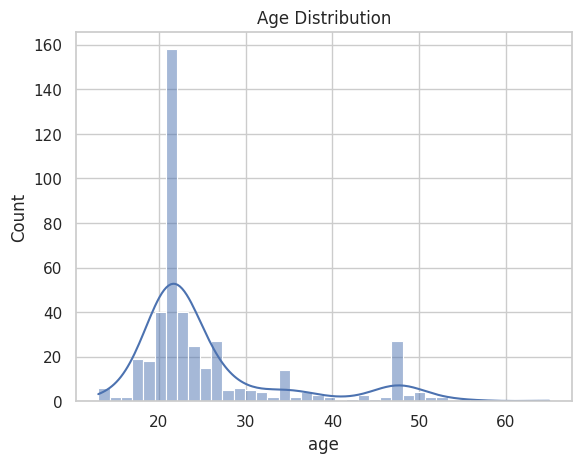

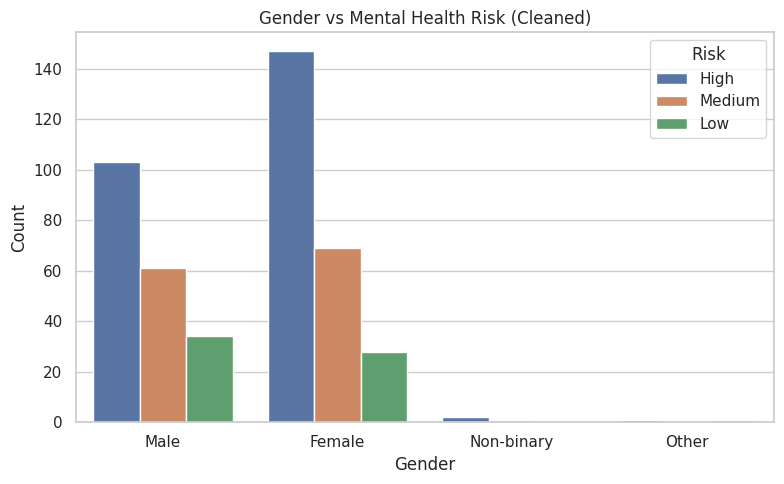

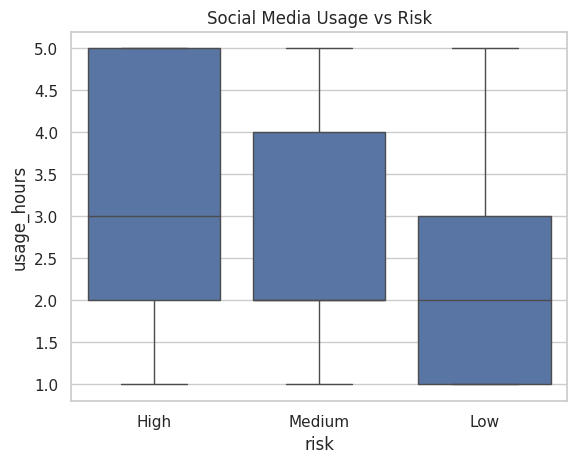

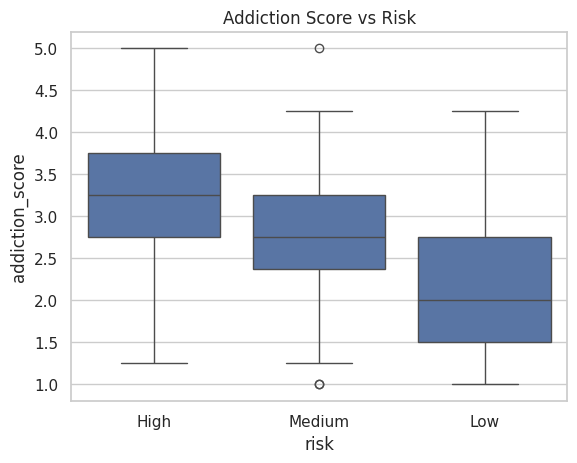

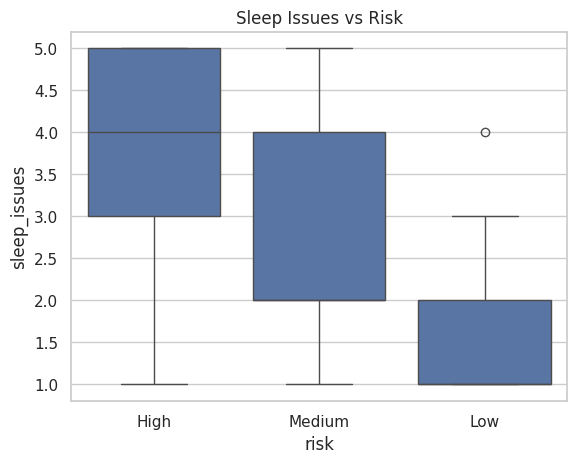

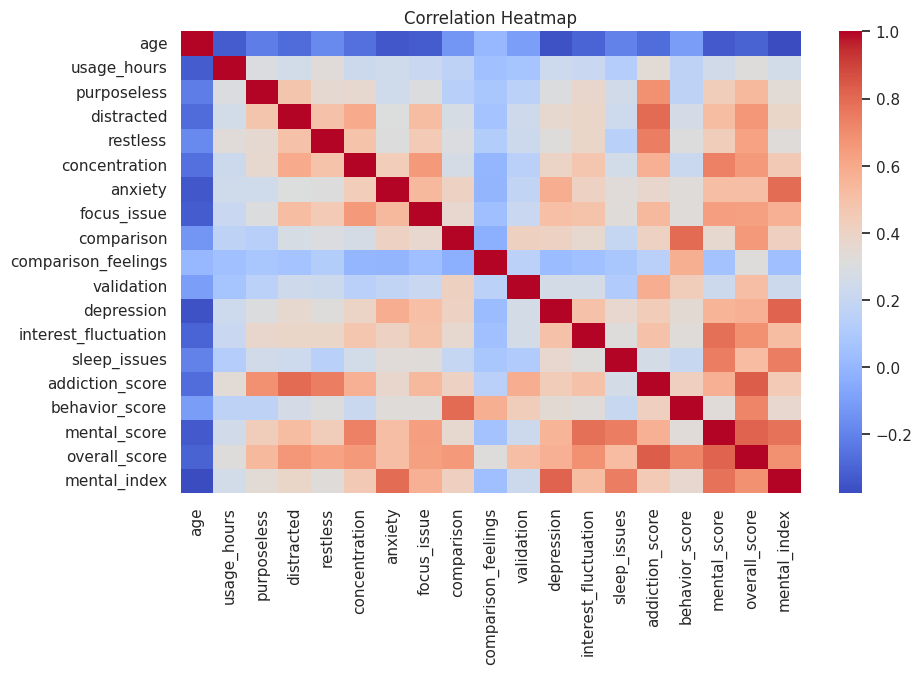

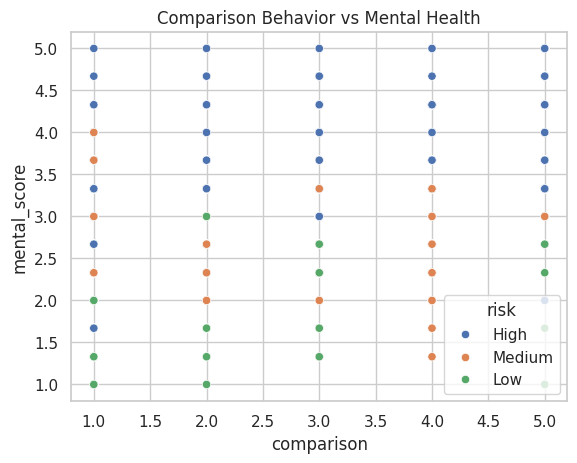

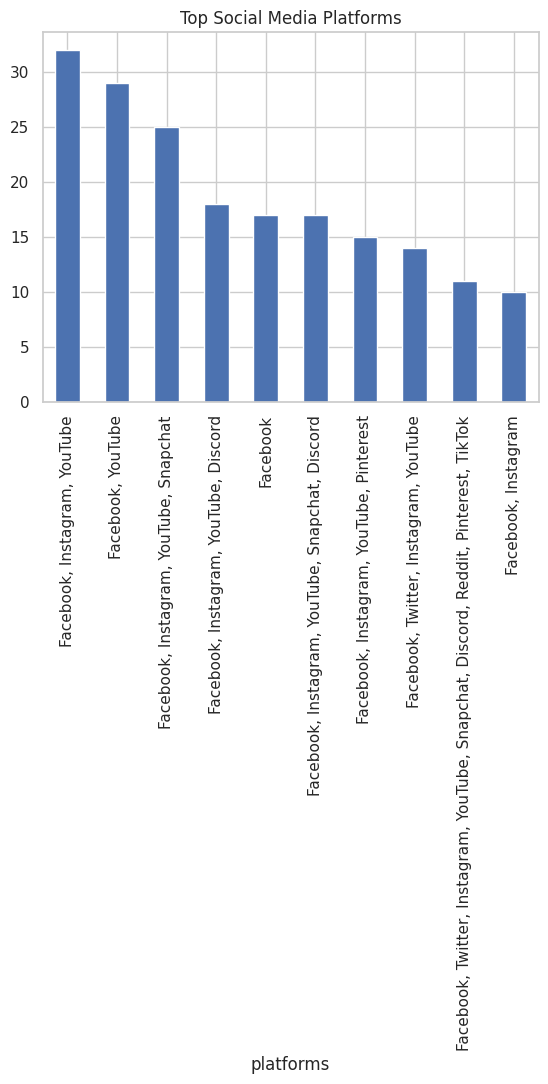

In [ ]:
#step-6
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# -------------------------------
# 1. Age Distribution
# -------------------------------
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


# -------------------------------
# 2. Gender vs Mental Health Risk
# Clean gender values
df['gender'] = df['gender'].str.lower().str.strip()

# Standardize categories
df['gender'] = df['gender'].replace({
    'male': 'Male',
    'female': 'Female',
    'nonbinary': 'Non-binary',
    'non-binary': 'Non-binary',
    'non binary': 'Non-binary',
    'non-binary unsure': 'Non-binary',
    'others???': 'Other',
    'other': 'Other'
})

# Keep only main categories (optional but recommended)
df['gender'] = df['gender'].apply(
    lambda x: x if x in ['Male', 'Female', 'Non-binary', 'Other'] else 'Other'
)
plt.figure(figsize=(8,5))

sns.countplot(x='gender', hue='risk', data=df,
              order=['Male','Female','Non-binary','Other'])

plt.title("Gender vs Mental Health Risk (Cleaned)")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Risk")

plt.tight_layout()
plt.show()

# -------------------------------
# 3. Usage Hours vs Risk
# -------------------------------
plt.figure()
sns.boxplot(x='risk', y='usage_hours', data=df)
plt.title("Social Media Usage vs Risk")
plt.show()


# -------------------------------
# 4. Addiction Score vs Risk
# -------------------------------
plt.figure()
sns.boxplot(x='risk', y='addiction_score', data=df)
plt.title("Addiction Score vs Risk")
plt.show()


# -------------------------------
# 5. Sleep Issues vs Risk
# -------------------------------
plt.figure()
sns.boxplot(x='risk', y='sleep_issues', data=df)
plt.title("Sleep Issues vs Risk")
plt.show()


# -------------------------------
# 6. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# -------------------------------
# 7. Comparison vs Mental Score
# -------------------------------
plt.figure()
sns.scatterplot(x='comparison', y='mental_score', hue='risk', data=df)
plt.title("Comparison Behavior vs Mental Health")
plt.show()


# -------------------------------
# 8. Top Platforms Used
# -------------------------------
plt.figure()
df['platforms'].value_counts().head(10).plot(kind='bar')
plt.title("Top Social Media Platforms")
plt.show()

In [ ]:
# STEP 7: Feature Selection + Encoding

from sklearn.preprocessing import LabelEncoder

# 🔹 1. Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 🔹 2. Define Features (X) and Target (y)

# REMOVE leakage columns
X = df.drop(['risk', 'mental_index', 'depression', 'anxiety', 'sleep_issues'], axis=1)

y = df['risk']

# 🔹 3. Check data
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Feature Shape: (447, 20)
Target Shape: (447,)


,age,gender,relationship,occupation,org_type,platforms,usage_hours,purposeless,distracted,restless,concentration,focus_issue,comparison,comparison_feelings,validation,interest_fluctuation,addiction_score,behavior_score,mental_score,overall_score
0,21.0,1,1,3,10,48,2.0,5,3,2,5,5,2,3,2,4,3.00,2.5,4.67,3.39
1,21.0,0,3,3,10,48,5.0,4,3,2,4,4,5,1,1,4,2.50,3.0,4.33,3.28
2,21.0,0,3,3,10,20,3.0,3,2,1,2,4,3,3,1,2,1.75,3.0,3.00,2.58
3,21.0,0,3,3,10,5,5.0,4,2,1,3,3,5,1,2,3,2.25,3.0,2.67,2.64
4,21.0,0,3,3,10,13,2.0,3,5,4,4,5,3,3,3,4,3.75,3.0,3.00,3.25


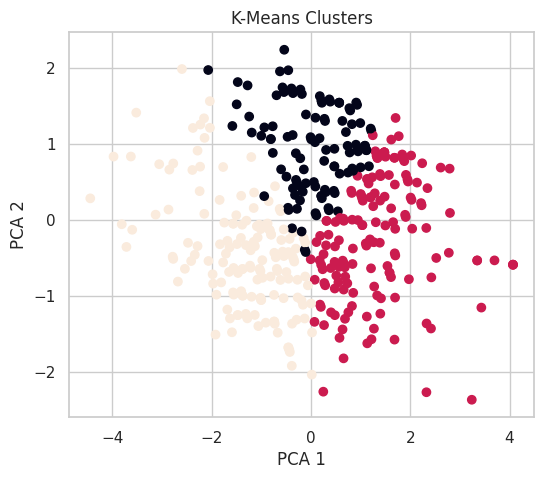

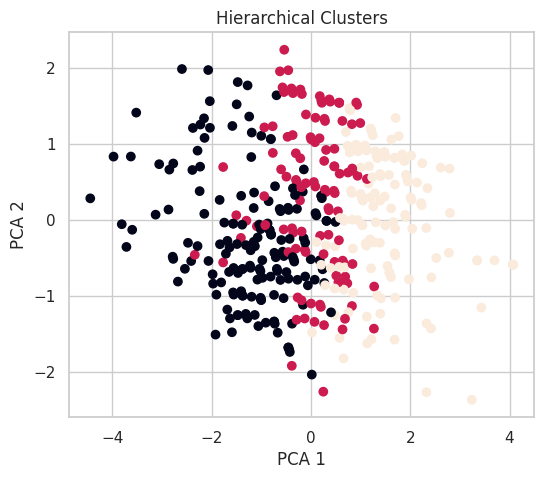

K-Means Cluster Summary:

                usage_hours  addiction_score  behavior_score  mental_score
kmeans_cluster                                                            
0                  4.422018         3.034404        2.545872      3.113303
1                  3.565789         3.758224        3.401316      4.041447
2                  1.870130         2.418831        2.480519      2.738377

Hierarchical Cluster Summary:

              usage_hours  addiction_score  behavior_score  mental_score
hier_cluster                                                            
0                2.066265         2.500000        2.334337      2.883614
1                3.831858         3.035398        2.982301      2.943982
2                3.941176         3.797794        3.323529      4.147132


In [ ]:
# STEP 8: CLUSTERING (KMeans + Hierarchical) - FINAL CLEAN VERSION

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------------------------------
# 1. Select Features for Clustering
# -------------------------------
cluster_features = [
    'usage_hours', 'addiction_score',
    'behavior_score', 'mental_score'
]

# -------------------------------
# 2. Handle Missing Values (IMPORTANT FIX)
# -------------------------------
X_cluster = df[cluster_features].dropna()

# Keep same rows in df
df = df.loc[X_cluster.index]

# -------------------------------
# 3. Scale Data
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# -------------------------------
# 4. K-Means Clustering
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# -------------------------------
# 5. Hierarchical Clustering
# -------------------------------
hierarchical = AgglomerativeClustering(n_clusters=3)
df['hier_cluster'] = hierarchical.fit_predict(X_scaled)

# -------------------------------
# 6. PCA for Visualization
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# 7. Plot K-Means Clusters
# -------------------------------
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'])
plt.title("K-Means Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# -------------------------------
# 8. Plot Hierarchical Clusters
# -------------------------------
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['hier_cluster'])
plt.title("Hierarchical Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# -------------------------------
# 9. Cluster Interpretation
# -------------------------------
print("K-Means Cluster Summary:\n")
print(df.groupby('kmeans_cluster')[cluster_features].mean())

print("\nHierarchical Cluster Summary:\n")
print(df.groupby('hier_cluster')[cluster_features].mean())


Logistic Regression
Accuracy: 0.7710843373493976
CV Mean: 0.7566265060240963

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.85        49
           1       0.62      0.56      0.59         9
           2       0.67      0.72      0.69        25

    accuracy                           0.77        83
   macro avg       0.72      0.70      0.71        83
weighted avg       0.77      0.77      0.77        83



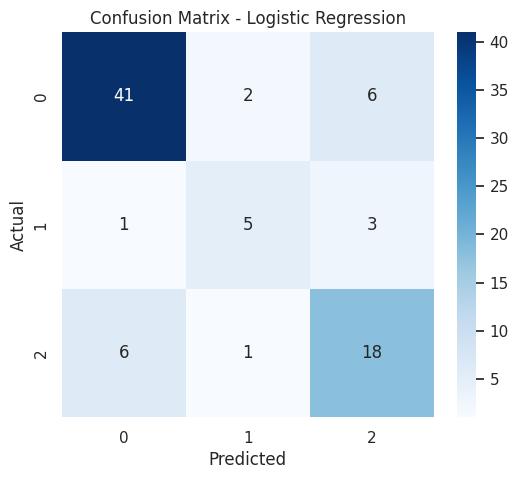

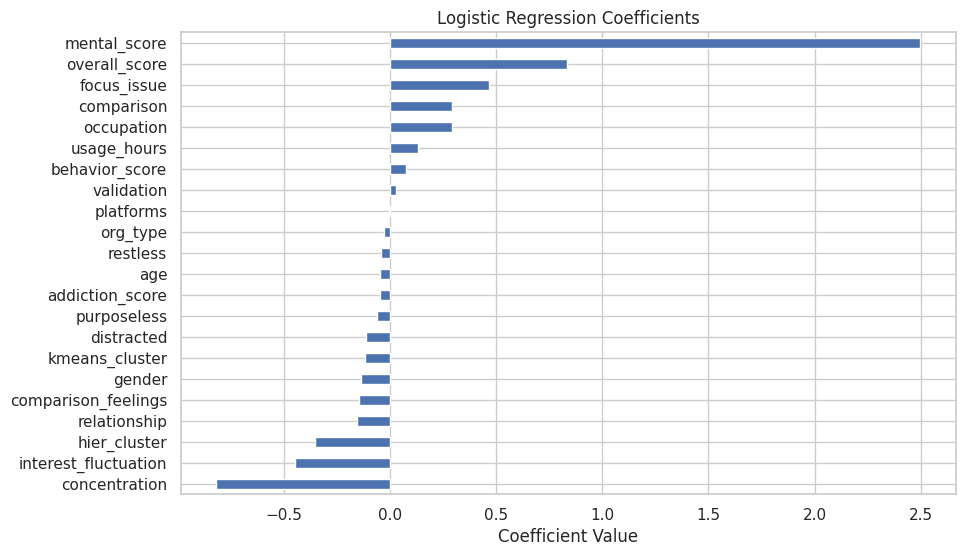


Decision Tree
Accuracy: 0.7108433734939759
CV Mean: 0.6867469879518073

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        49
           1       0.67      0.44      0.53         9
           2       0.57      0.64      0.60        25

    accuracy                           0.71        83
   macro avg       0.68      0.63      0.64        83
weighted avg       0.71      0.71      0.71        83



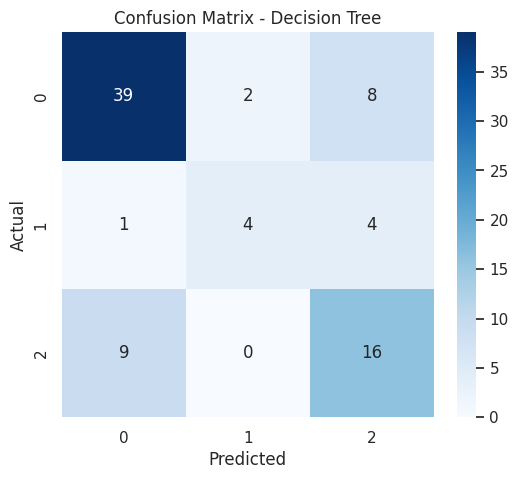

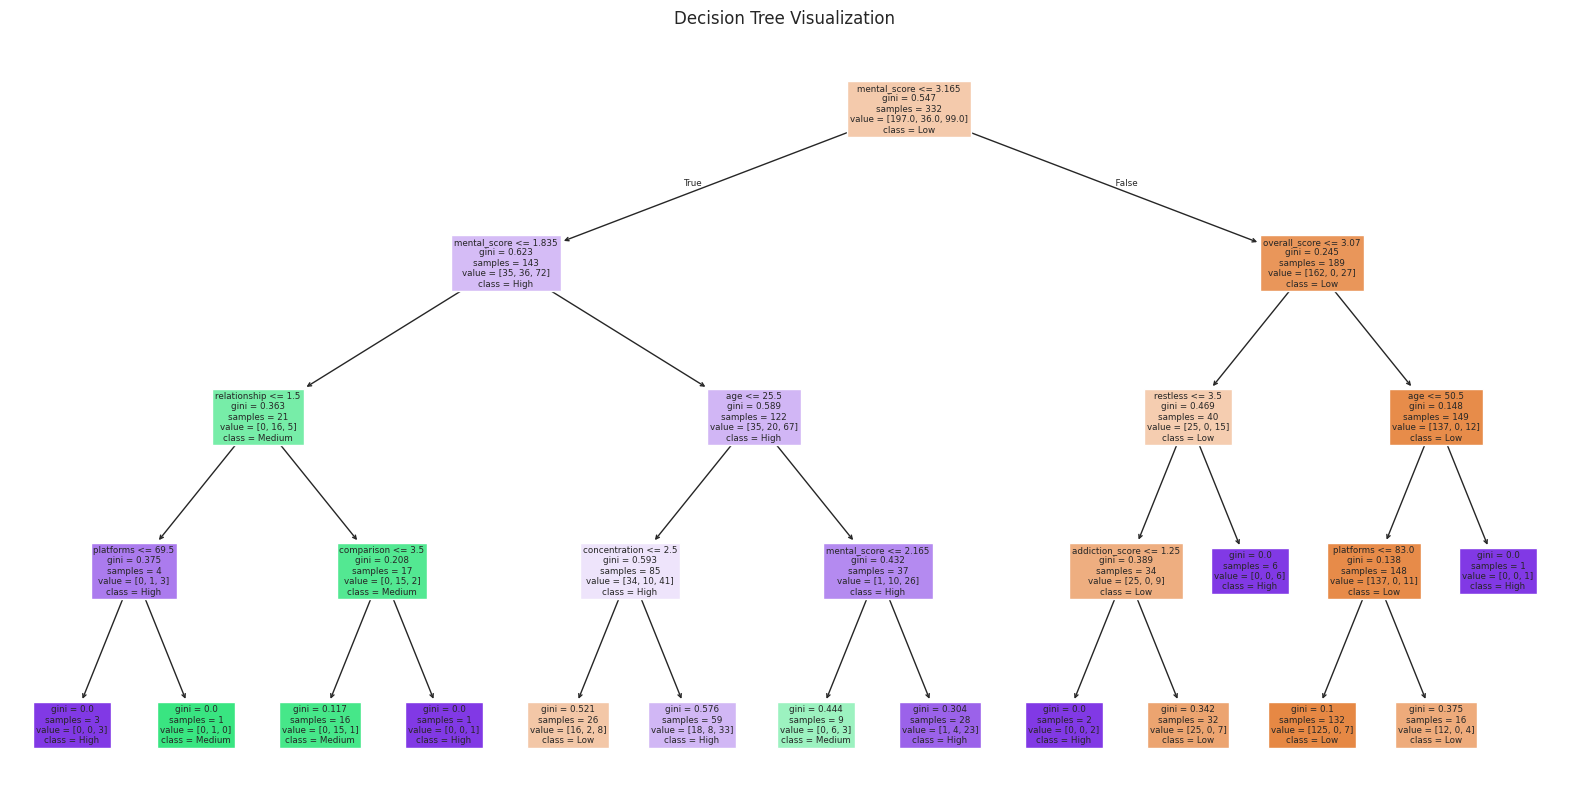


Random Forest
Accuracy: 0.7831325301204819
CV Mean: 0.7325301204819278

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.88      0.83        49
           1       0.86      0.67      0.75         9
           2       0.73      0.64      0.68        25

    accuracy                           0.78        83
   macro avg       0.79      0.73      0.76        83
weighted avg       0.78      0.78      0.78        83



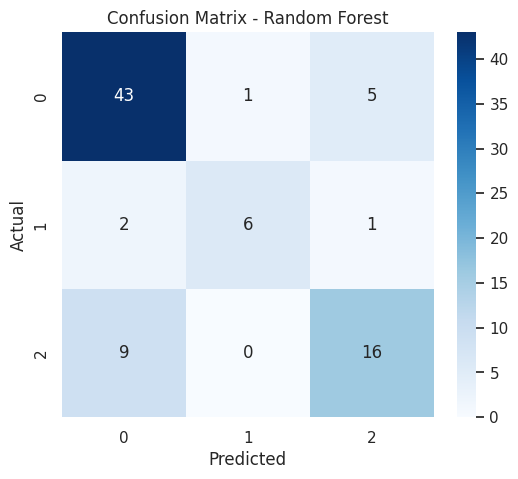

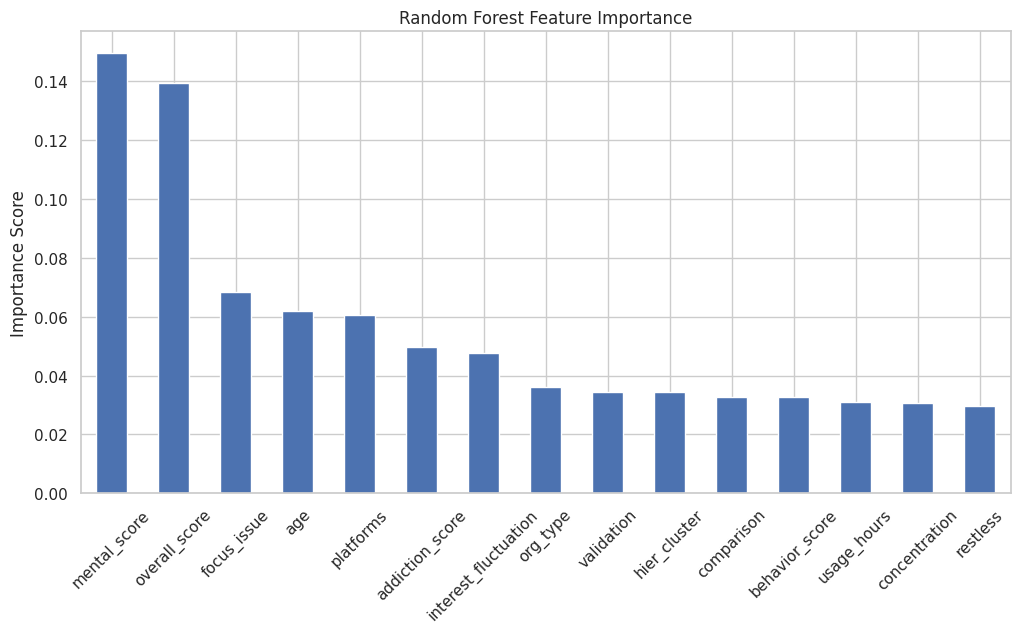


SVM
Accuracy: 0.6265060240963856
CV Mean: 0.616867469879518

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.96      0.78        49
           1       0.00      0.00      0.00         9
           2       0.45      0.20      0.28        25

    accuracy                           0.63        83
   macro avg       0.37      0.39      0.35        83
weighted avg       0.52      0.63      0.54        83



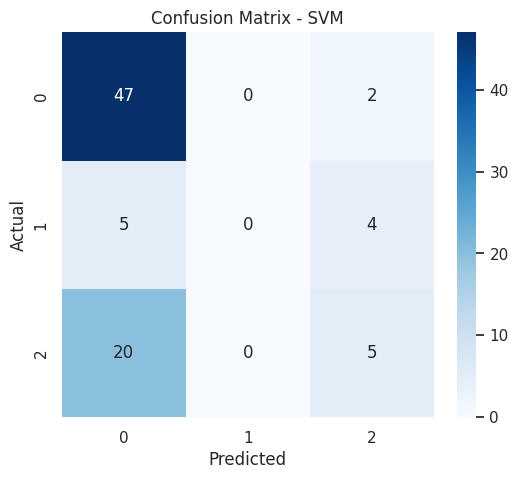

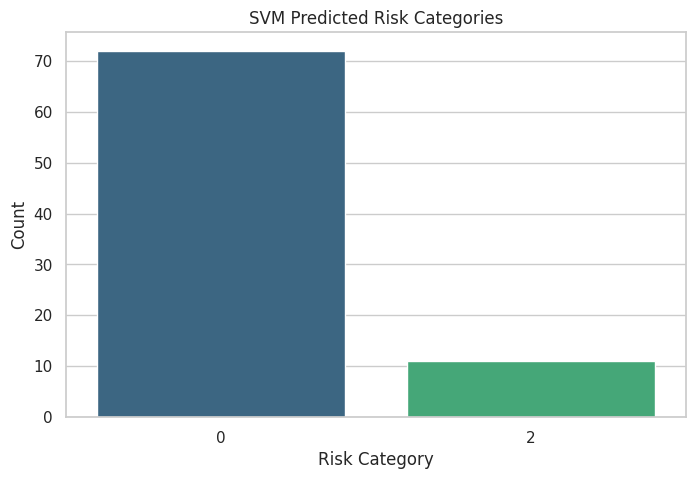


Gradient Boosting
Accuracy: 0.7590361445783133
CV Mean: 0.727710843373494

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        49
           1       0.75      0.67      0.71         9
           2       0.65      0.68      0.67        25

    accuracy                           0.76        83
   macro avg       0.74      0.72      0.73        83
weighted avg       0.76      0.76      0.76        83



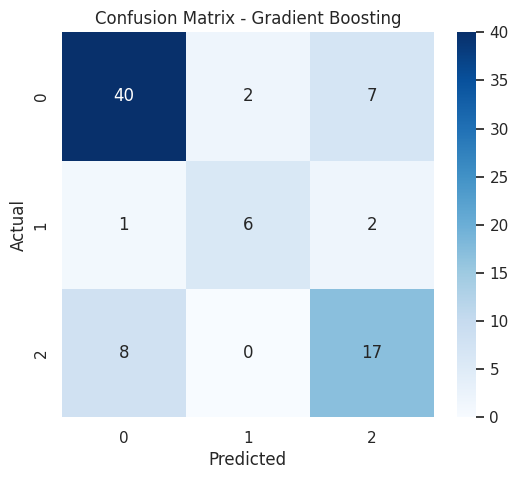

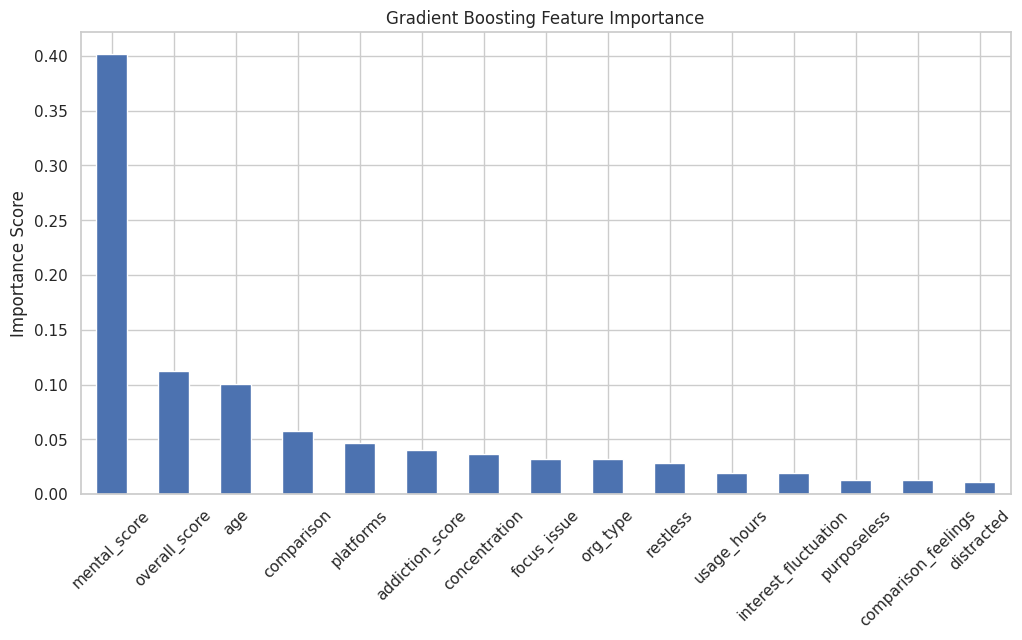


XGBoost
Accuracy: 0.7710843373493976
CV Mean: 0.7084337349397591

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        49
           1       0.78      0.78      0.78         9
           2       0.67      0.64      0.65        25

    accuracy                           0.77        83
   macro avg       0.75      0.75      0.75        83
weighted avg       0.77      0.77      0.77        83



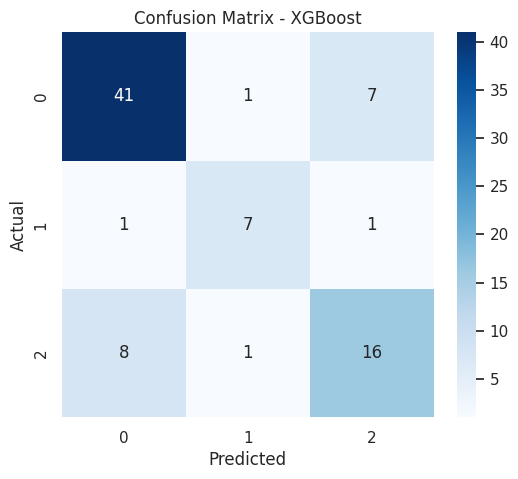

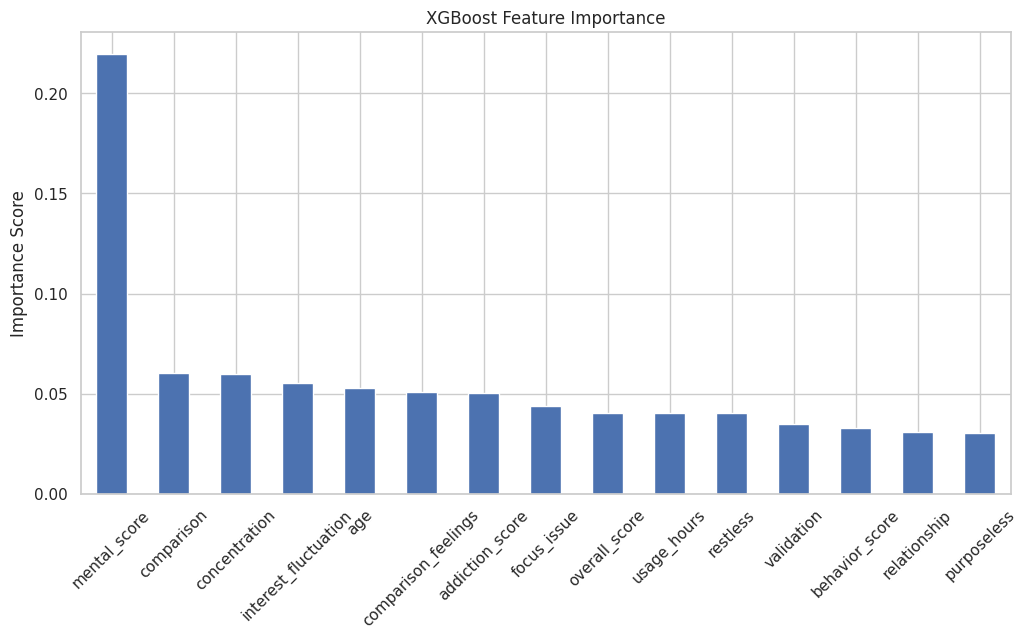


MODEL COMPARISON
                 Model  Test Accuracy  CV Mean  CV Std
2        Random Forest         0.7831   0.7325  0.0376
0  Logistic Regression         0.7711   0.7566  0.0413
5              XGBoost         0.7711   0.7084  0.0427
4    Gradient Boosting         0.7590   0.7277  0.0435
1        Decision Tree         0.7108   0.6867  0.0202
3                  SVM         0.6265   0.6169  0.0234


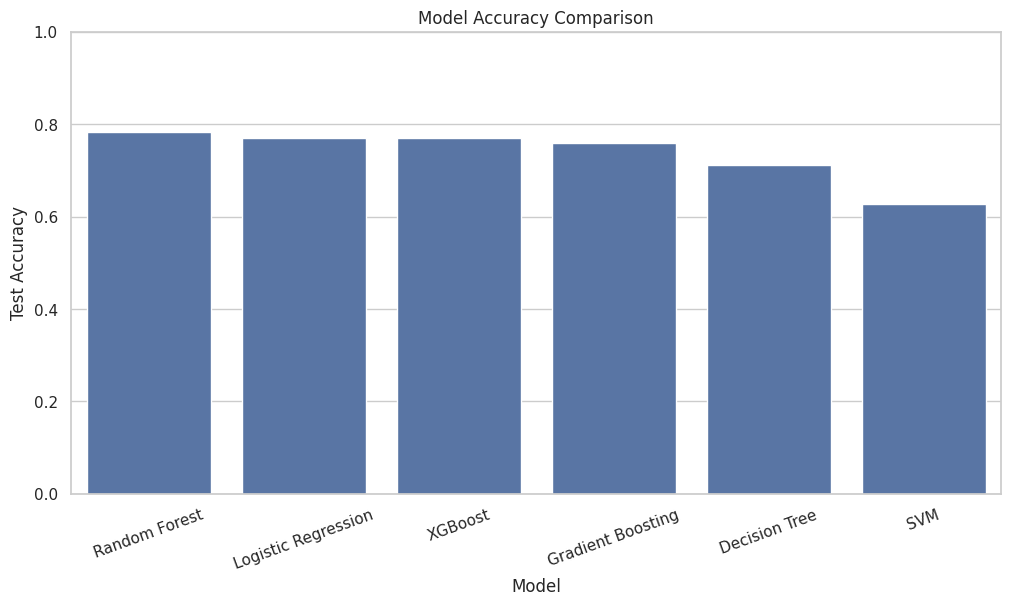


Best Model: Random Forest


In [ ]:
# =========================================================
# STEP 9 (UPGRADED): MODELS + INDIVIDUAL VISUALIZATIONS
# =========================================================

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# 1. DEFINE FEATURES & TARGET
# =========================================================

X = df.drop(
    ['risk', 'mental_index', 'depression', 'anxiety', 'sleep_issues'],
    axis=1
)

y = df['risk']

# =========================================================
# 2. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 3. DEFINE MODELS
# =========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42, max_depth=4),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=150,
            random_state=42
        ),

    "SVM":
        SVC(kernel='rbf', probability=True),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)
}

# =========================================================
# OPTIONAL : XGBOOST
# =========================================================

try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )

except:
    print("XGBoost not installed")

# =========================================================
# 4. TRAIN + EVALUATE + PLOTS
# =========================================================

results = []
trained_models = {}

for name, model in models.items():

    # ----------------------------------
    # TRAIN MODEL
    # ----------------------------------

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    # ----------------------------------
    # CROSS VALIDATION
    # ----------------------------------

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    # ----------------------------------
    # SAVE RESULTS
    # ----------------------------------

    results.append({

        "Model": name,
        "Test Accuracy": round(acc, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4)

    })

    trained_models[name] = model

    # ----------------------------------
    # PRINT RESULTS
    # ----------------------------------

    print("\n===================================")
    print(name)
    print("===================================")

    print("Accuracy:", acc)
    print("CV Mean:", cv_scores.mean())

    print("\nClassification Report:\n")

    print(classification_report(y_test, pred))

    # =====================================================
    # CONFUSION MATRIX PLOT
    # =====================================================

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # =====================================================
    # LOGISTIC REGRESSION COEFFICIENT PLOT
    # =====================================================

    if name == "Logistic Regression":

        coef = pd.Series(
            model.coef_[0],
            index=X.columns
        )

        coef.sort_values().plot(
            kind='barh',
            figsize=(10,6)
        )

        plt.title("Logistic Regression Coefficients")

        plt.xlabel("Coefficient Value")

        plt.show()

    # =====================================================
    # DECISION TREE VISUALIZATION
    # =====================================================

    if name == "Decision Tree":

        plt.figure(figsize=(20,10))

        plot_tree(
            model,
            filled=True,
            feature_names=X.columns,
            class_names=['Low', 'Medium', 'High']
        )

        plt.title("Decision Tree Visualization")

        plt.show()

    # =====================================================
    # RANDOM FOREST FEATURE IMPORTANCE
    # =====================================================

    if name == "Random Forest":

        importance = pd.Series(
            model.feature_importances_,
            index=X.columns
        )

        importance.sort_values(
            ascending=False
        ).head(15).plot(
            kind='bar',
            figsize=(12,6)
        )

        plt.title("Random Forest Feature Importance")

        plt.ylabel("Importance Score")

        plt.xticks(rotation=45)

        plt.show()

    # =====================================================
    # SVM SUPPORT VECTOR PLOT
    # =====================================================

    if name == "SVM":

        plt.figure(figsize=(8,5))

        sns.countplot(
            x=pred,
            palette='viridis'
        )

        plt.title("SVM Predicted Risk Categories")

        plt.xlabel("Risk Category")
        plt.ylabel("Count")

        plt.show()

    # =====================================================
    # GRADIENT BOOSTING FEATURE IMPORTANCE
    # =====================================================

    if name == "Gradient Boosting":

        gb_importance = pd.Series(
            model.feature_importances_,
            index=X.columns
        )

        gb_importance.sort_values(
            ascending=False
        ).head(15).plot(
            kind='bar',
            figsize=(12,6)
        )

        plt.title("Gradient Boosting Feature Importance")

        plt.ylabel("Importance Score")

        plt.xticks(rotation=45)

        plt.show()

    # =====================================================
    # XGBOOST FEATURE IMPORTANCE
    # =====================================================

    if name == "XGBoost":

        xgb_importance = pd.Series(
            model.feature_importances_,
            index=X.columns
        )

        xgb_importance.sort_values(
            ascending=False
        ).head(15).plot(
            kind='bar',
            figsize=(12,6)
        )

        plt.title("XGBoost Feature Importance")

        plt.ylabel("Importance Score")

        plt.xticks(rotation=45)

        plt.show()

# =========================================================
# 5. MODEL COMPARISON TABLE
# =========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

print("\n===================================")
print("MODEL COMPARISON")
print("===================================")

print(results_df)

# =========================================================
# 6. MODEL ACCURACY COMPARISON PLOT
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Test Accuracy',
    data=results_df
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# 7. BEST MODEL
# =========================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)

# =========================================================
# 8. PREDICTION FUNCTION
# =========================================================

def predict_risk(input_data):

    input_df = pd.DataFrame([input_data])

    input_df = input_df[X.columns]

    prediction = best_model.predict(input_df)[0]

    return prediction

In [ ]:
# LIVE DEMO (to test impact of social media on mental health )

import pandas as pd

# Example examiner input (you can change values live)
sample_input = {
    'age': 22,
    'gender': 1,
    'relationship': 0,
    'occupation': 0,
    'org_type': 0,
    'platforms': 0,
    'usage_hours': 5,

    'purposeless': 4,
    'distracted': 4,
    'restless': 3,
    'concentration': 3,
    'focus_issue': 0,
    'comparison': 4,
    'comparison_feelings': 3,
    'validation': 4,
    'interest_fluctuation': 3
}

# 🔹 Feature Engineering
addiction_score = (sample_input['purposeless'] + sample_input['distracted'] + sample_input['restless'] + sample_input['validation']) / 4
behavior_score = (sample_input['comparison'] + sample_input['comparison_feelings']) / 2
mental_score = (sample_input['concentration'] + sample_input['interest_fluctuation']) / 2
overall_score = (addiction_score + behavior_score + mental_score) / 3

sample_input['addiction_score'] = round(addiction_score,2)
sample_input['behavior_score'] = round(behavior_score,2)
sample_input['mental_score'] = round(mental_score,2)
sample_input['overall_score'] = round(overall_score,2)

# 🔹 Convert to DataFrame
input_df = pd.DataFrame([sample_input])

# Match training columns
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# 🔹 Predict
prediction = best_model.predict(input_df)[0]

print("🔮 Predicted Mental Health Risk:", prediction)

🔮 Predicted Mental Health Risk: 2


In [ ]:

# LIVE PREDICTION SYSTEM
# Social Media & Mental Health Risk Predictor

import pandas as pd

def predict_mental_health(age, gender, relationship, occupation, org_type,
                           platforms, usage_hours, purposeless, distracted,
                           restless, concentration, focus_issue,
                           comparison, comparison_feelings, validation,
                           interest_fluctuation):

    # ─── STEP 1: Feature Engineering ───────────────────────
    addiction_score  = round((purposeless + distracted + restless + validation) / 4, 2)
    behavior_score   = round((comparison + comparison_feelings) / 2, 2)
    mental_score     = round((concentration + interest_fluctuation) / 2, 2)
    overall_score    = round((addiction_score + behavior_score + mental_score) / 3, 2)

    # ─── STEP 2: Build Input DataFrame ──────────────────────
    sample_input = {
        'age': age,
        'gender': gender,
        'relationship': relationship,
        'occupation': occupation,
        'org_type': org_type,
        'platforms': platforms,
        'usage_hours': usage_hours,
        'purposeless': purposeless,
        'distracted': distracted,
        'restless': restless,
        'concentration': concentration,
        'focus_issue': focus_issue,
        'comparison': comparison,
        'comparison_feelings': comparison_feelings,
        'validation': validation,
        'interest_fluctuation': interest_fluctuation,
        'addiction_score': addiction_score,
        'behavior_score': behavior_score,
        'mental_score': mental_score,
        'overall_score': overall_score
    }

    input_df = pd.DataFrame([sample_input])
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    # ─── STEP 3: Predict ────────────────────────────────────
    prediction     = best_model.predict(input_df)[0]
    probabilities  = best_model.predict_proba(input_df)[0]
    classes        = best_model.classes_

    # Map numeric to label
    risk_map = {0: "Low", 1: "Medium", 2: "High"}
    if isinstance(prediction, (int, float)):
        risk_label = risk_map.get(int(prediction), str(prediction))
    else:
        risk_label = str(prediction)

    # ─── STEP 4: Risk Level Settings ────────────────────────
    if risk_label == "High":
        emoji       = "🔴"
        advice      = "Immediate attention recommended. Please consider speaking to a mental health professional."
        usage_tip   = "Try to limit social media use to under 2 hours per day."
        behavior_tip= "Avoid comparing yourself with others online. Focus on your own growth."
        sleep_tip   = "Establish a proper sleep schedule. Avoid screens 1 hour before bed."
    elif risk_label == "Medium":
        emoji       = "🟡"
        advice      = "Moderate risk detected. Small lifestyle changes can help significantly."
        usage_tip   = "Try to reduce daily usage by 30 minutes each week."
        behavior_tip= "Be mindful of how social media content makes you feel."
        sleep_tip   = "Maintain consistent sleep timings and reduce late-night scrolling."
    else:
        emoji       = "🟢"
        advice      = "Low risk detected. Keep maintaining healthy social media habits."
        usage_tip   = "Continue using social media mindfully and purposefully."
        behavior_tip= "Keep a positive mindset and limit unnecessary browsing."
        sleep_tip   = "Your sleep patterns appear healthy. Keep it up!"

    # ─── STEP 5: Addiction Level Label ──────────────────────
    if addiction_score >= 4:
        addiction_level = "Very High 🔴"
    elif addiction_score >= 3:
        addiction_level = "High 🟠"
    elif addiction_score >= 2:
        addiction_level = "Moderate 🟡"
    else:
        addiction_level = "Low 🟢"

    # ─── STEP 6: Print Full Summary ─────────────────────────
    print("=" * 60)
    print("       MENTAL HEALTH RISK ASSESSMENT REPORT")
    print("=" * 60)

    print("\n📋 PERSONAL INFORMATION")
    print("-" * 40)
    print(f"  Age             : {age} years")
    print(f"  Gender          : {'Male' if gender == 1 else 'Female' if gender == 0 else 'Other'}")
    print(f"  Occupation      : {'Student' if occupation == 0 else 'Working Professional' if occupation == 1 else 'Other'}")
    print(f"  Relationship    : {'Single' if relationship == 0 else 'In a Relationship' if relationship == 1 else 'Other'}")

    print("\n📱 SOCIAL MEDIA USAGE")
    print("-" * 40)
    print(f"  Daily Usage     : {usage_hours} hours/day")
    print(f"  Purposeless Use : {purposeless}/5")
    print(f"  Distraction     : {distracted}/5")
    print(f"  Restlessness    : {restless}/5")
    print(f"  Validation Seek : {validation}/5")

    print("\n🧠 PSYCHOLOGICAL INDICATORS")
    print("-" * 40)
    print(f"  Concentration   : {concentration}/5")
    print(f"  Comparison      : {comparison}/5")
    print(f"  Comp. Feelings  : {comparison_feelings}/5")
    print(f"  Interest Fluct. : {interest_fluctuation}/5")
    print(f"  Focus Issues    : {'Yes' if focus_issue == 1 else 'No'}")

    print("\n📊 CALCULATED SCORES")
    print("-" * 40)
    print(f"  Addiction Score : {addiction_score}/5  → {addiction_level}")
    print(f"  Behavior Score  : {behavior_score}/5")
    print(f"  Mental Score    : {mental_score}/5")
    print(f"  Overall Score   : {overall_score}/5")

    print("\n🎯 PREDICTION RESULT")
    print("-" * 40)
    print(f"  Risk Level      : {emoji} {risk_label} Risk")

    print("\n📈 PROBABILITY BREAKDOWN")
    print("-" * 40)
    for cls, prob in zip(classes, probabilities):
        label = risk_map.get(int(cls), str(cls)) if isinstance(cls, (int, float)) else str(cls)
        bar   = "█" * int(prob * 30)
        print(f"  {label:8s} Risk : {bar:30s} {prob*100:.1f}%")

    print("\n💡 RECOMMENDATIONS")
    print("-" * 40)
    print(f"  Overall  : {advice}")
    print(f"  Usage    : {usage_tip}")
    print(f"  Behavior : {behavior_tip}")
    print(f"  Sleep    : {sleep_tip}")

    print("\n⚠️  RISK INDICATORS DETECTED")
    print("-" * 40)
    if usage_hours >= 4:
        print("  ⚠️  Very high daily usage (4+ hours)")
    if addiction_score >= 3.5:
        print("  ⚠️  High addiction score detected")
    if comparison >= 4:
        print("  ⚠️  Frequent self-comparison behavior")
    if validation >= 4:
        print("  ⚠️  High validation-seeking behavior")
    if mental_score >= 3.5:
        print("  ⚠️  High mental health score — psychological distress likely")
    if purposeless >= 4:
        print("  ⚠️  Frequent purposeless social media use")
    if distracted >= 4:
        print("  ⚠️  High distraction level during daily tasks")
    if restless >= 4:
        print("  ⚠️  High restlessness without social media")

    print("\n" + "=" * 60)
    print("        END OF REPORT")
    print("=" * 60)

    return risk_label


# ============================================================
# RUN THE PREDICTOR — CHANGE VALUES HERE
# ============================================================

predict_mental_health(
    age                  = 22,
    gender               = 1,       # 1 = Male, 0 = Female
    relationship         = 0,       # 0 = Single, 1 = In Relationship
    occupation           = 0,       # 0 = Student, 1 = Working
    org_type             = 0,
    platforms            = 0,
    usage_hours          = 5,       # Hours per day
    purposeless          = 4,       # Scale 1-5
    distracted           = 4,       # Scale 1-5
    restless             = 3,       # Scale 1-5
    concentration        = 3,       # Scale 1-5
    focus_issue          = 0,       # 0 = No, 1 = Yes
    comparison           = 4,       # Scale 1-5
    comparison_feelings  = 3,       # Scale 1-5
    validation           = 4,       # Scale 1-5
    interest_fluctuation = 3        # Scale 1-5
)

       MENTAL HEALTH RISK ASSESSMENT REPORT

📋 PERSONAL INFORMATION
----------------------------------------
  Age             : 22 years
  Gender          : Male
  Occupation      : Student
  Relationship    : Single

📱 SOCIAL MEDIA USAGE
----------------------------------------
  Daily Usage     : 5 hours/day
  Purposeless Use : 4/5
  Distraction     : 4/5
  Restlessness    : 3/5
  Validation Seek : 4/5

🧠 PSYCHOLOGICAL INDICATORS
----------------------------------------
  Concentration   : 3/5
  Comparison      : 4/5
  Comp. Feelings  : 3/5
  Interest Fluct. : 3/5
  Focus Issues    : No

📊 CALCULATED SCORES
----------------------------------------
  Addiction Score : 3.75/5  → High 🟠
  Behavior Score  : 3.5/5
  Mental Score    : 3.0/5
  Overall Score   : 3.42/5

🎯 PREDICTION RESULT
----------------------------------------
  Risk Level      : 🟢 2 Risk

📈 PROBABILITY BREAKDOWN
----------------------------------------
  0        Risk : ███████████                    39.3%
  1        Ri

'2'